In [1]:
import pandas as pd

In [2]:
import scipy.stats as st

In [3]:
!pip install seaborn

In [4]:
import seaborn as sns

In [25]:
df = pd.read_csv("baseball.csv")

In [26]:
df.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424


In [27]:
df.RS.mean()

np.float64(715.0819805194806)

In [28]:
df.loc[df.Team == "ARI"].RS.mean()

np.float64(742.2)

In [29]:
df.loc[(df.Team == "ARI") & (df.Year >= 2005)].RS.mean()

np.float64(724.875)

In [30]:
df.loc [(df.Team == "CHC") & ((df.Year <2000) | (df.Year > 2005))].RA.mean()

np.float64(725.4634146341464)

In [31]:
#Mean and Meadian of Wins (W)
print (df.W.mean())

80.90422077922078


In [32]:
print (df.W.median())

81.0


In [33]:
#What's the median of Wins of the Baltimore Team (BAL) until 2000?
df.loc [(df.Team == "BAL") & (df.Year <= 2000)].W.median()

np.float64(89.0)

## Mode

0.32633116883116886
0.326
0    0.322
Name: OBP, dtype: float64


<Axes: >

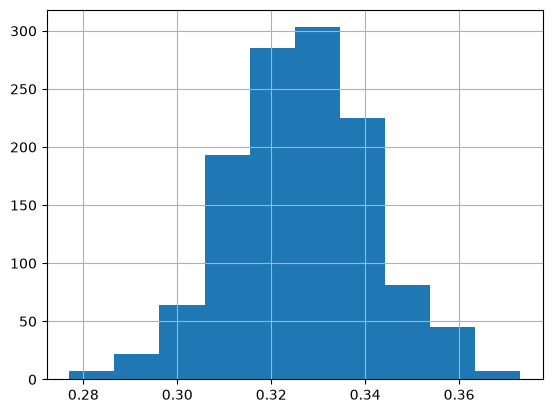

In [34]:
# Mode, mean and median of OBP
print(df.OBP.mean())
print(df.OBP.median())
print(df.OBP.mode())
df.OBP.hist() 

In [35]:
# Question: What is the Mode of OBP during the year 2010
df.loc[df.Year == 2010].OBP.mode()

0    0.332
Name: OBP, dtype: float64

In [36]:
#Question: Most common Season Ranking for Boston (BOS)
df.loc[df.Team == "BOS"].RankSeason.mode()

0    3.0
Name: RankSeason, dtype: float64

## Standard Deviation and Variance

In [37]:
# OOBP
print(f"Mean: {df.OOBP.mean()}")
print(f"STD sample: {df.OOBP.std()}") #Standard Deviation of the Sample
print(f"STD pop: {df.OOBP.std(ddof = 0)}") #Standard Deviation of the Population
print(f"Variance: {df.OOBP.std() * df.OOBP.std()}") #Variance of the population
print(f"Variance: {df.OOBP.var(ddof = 0)}") #Variance of the population

Mean: 0.3322642857142857
STD sample: 0.015295316041389943
STD pop: 0.015277096480377029
Variance: 0.00023394669280600052
Variance: 0.00023338967687074817


0.25927272727272727
0.012907228928000314
0.00016646133412042514


<Axes: >

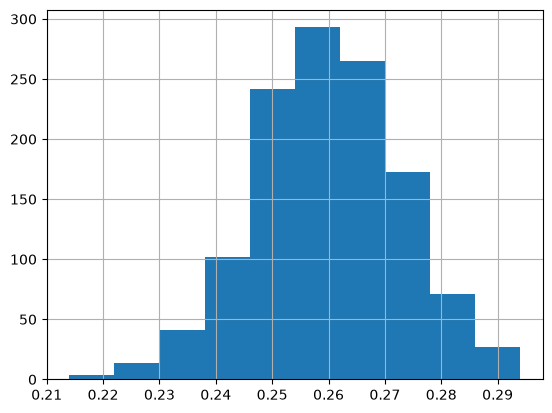

In [38]:
# What is the standard deviation of the sample of BA and the variance of the population
print(df.BA.mean())
print(df.BA.std())
print(df.BA.var(ddof = 0))
df.BA.hist()

### Coeficient of Variation 

In [39]:
# Function for descriptive Statistics
df.describe()

,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,244.000000,244.000000,1232.000000,420.000000,420.000000
mean,1988.957792,715.081981,715.081981,80.904221,0.326331,0.397342,0.259273,0.198052,3.122951,2.717213,161.918831,0.332264,0.419743
std,14.819625,91.534294,93.079933,11.458139,0.015013,0.033267,0.012907,0.398693,1.738349,1.095234,0.624365,0.015295,0.026510
min,1962.000000,463.000000,472.000000,40.000000,0.277000,0.301000,0.214000,0.000000,1.000000,1.000000,158.000000,0.294000,0.346000
25%,1976.750000,652.000000,649.750000,73.000000,0.317000,0.375000,0.251000,0.000000,2.000000,2.000000,162.000000,0.321000,0.401000
50%,1989.000000,711.000000,709.000000,81.000000,0.326000,0.396000,0.260000,0.000000,3.000000,3.000000,162.000000,0.331000,0.419000
75%,2002.000000,775.000000,774.250000,89.000000,0.337000,0.421000,0.268000,0.000000,4.000000,4.000000,162.000000,0.343000,0.438000
max,2012.000000,1009.000000,1103.000000,116.000000,0.373000,0.491000,0.294000,1.000000,8.000000,5.000000,165.000000,0.384000,0.499000


In [40]:
# Coefficient of variation for Runs Scored variable
cv = df.RS.std() / df.RS.mean()
print(f"The CV for RS is {cv}")

# As a rule of thumb, data with variability has a cv > 1

The CV for RS is 0.1280053148279153


In [41]:
# CV for Wins
cv_for_wins = df.W.std() / df.W.mean()
print(f"The CV for W is {cv_for_wins}")

The CV for W is 0.14162597377041425


## Covariance 

In [42]:
# Covariance with continuous variables
df_co = df[["RS", "RA", "W"]]
df_co.head()

,RS,RA,W
0,734,688,81
1,700,600,94
2,712,705,93
3,734,806,69
4,613,759,61


In [43]:
df_co.cov()

,RS,RA,W
RS,8378.526986,3238.783688,536.724349
RA,3238.783688,8663.873859,-567.810176
W,536.724349,-567.810176,131.288950


In [44]:
# Exercise - Pick 3 variables for the Covariance Matrix
df.head()

,Team,League,Year,RS,RA,W,OBP,SLG,BA,Playoffs,RankSeason,RankPlayoffs,G,OOBP,OSLG
0,ARI,NL,2012,734,688,81,0.328,0.418,0.259,0,NaN,NaN,162,0.317,0.415
1,ATL,NL,2012,700,600,94,0.320,0.389,0.247,1,4.0,5.0,162,0.306,0.378
2,BAL,AL,2012,712,705,93,0.311,0.417,0.247,1,5.0,4.0,162,0.315,0.403
3,BOS,AL,2012,734,806,69,0.315,0.415,0.260,0,NaN,NaN,162,0.331,0.428
4,CHC,NL,2012,613,759,61,0.302,0.378,0.240,0,NaN,NaN,162,0.335,0.424


In [45]:
df_co2 = df[["OBP", "SLG", "BA"]]
df_co2.cov()

,OBP,SLG,BA
OBP,0.000225,0.000395,0.000165
SLG,0.000395,0.001107,0.000339
BA,0.000165,0.000339,0.000167


## Correlation

In [46]:
# Correlation Matrix
df_co.corr()


,RS,RA,W
RS,1.000000,0.380139,0.511745
RA,0.380139,1.000000,-0.532394
W,0.511745,-0.532394,1.000000


<Axes: >

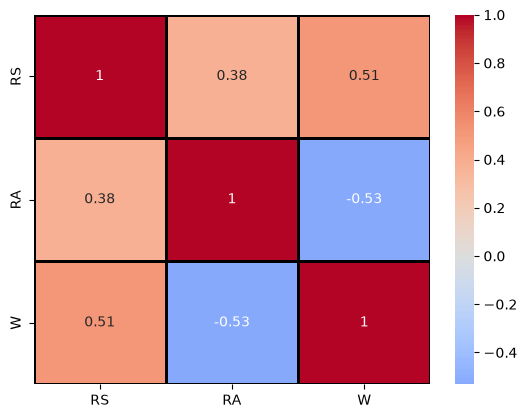

In [47]:
#Visualization via heatmap
sns.heatmap(data = df_co.corr(),
            annot = True,
            center = 0,
            cmap = 'coolwarm',
            linewidths = 1,
            linecolor = 'black')

<Axes: >

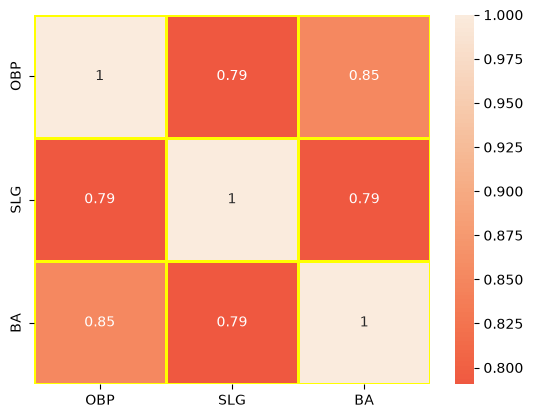

In [48]:
# Do correlation matrix, visualize it but change at least 
sns.heatmap(data = df_co2.corr(),
            annot = True,
            center = 0.7,
            cmap = 'rocket',
            linewidths = 1,
            linecolor = 'yellow')

## Normal Distribution

<Axes: ylabel='Density'>

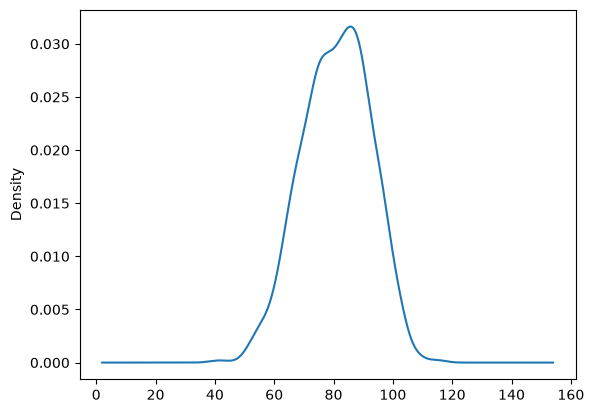

In [49]:
# Plotting W
df.W.plot.density()

In [50]:
# 68-95-99 check
print(df.loc[(df.W <= df.W.mean() + 3 * df.W.std()) &
       (df.W >= df.W.mean() - 3 * df.W.std())].W.count()/df.W.count())

0.997564935064935


<Axes: ylabel='Density'>

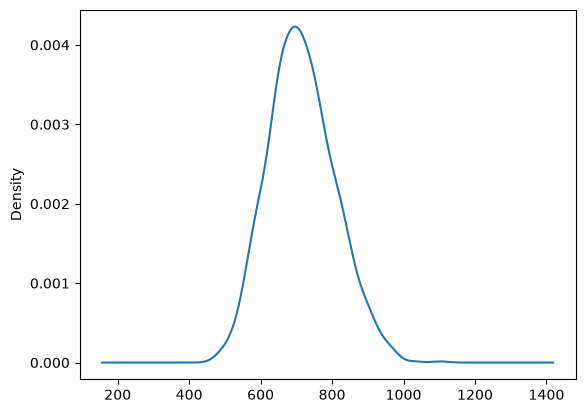

In [53]:
# Density plot for RAs
df.RA.plot.density()

In [56]:
# Exercise - Do the 68-95-99 check, but use a for plot 
for i in range(1, 4):
    print(df.loc[(df.RA <= df.RA.mean() + i * df.RA.std()) &
           (df.RA >= df.RA.mean() - i * df.RA.std())].RA.count()/df.RA.count())


0.674512987012987
0.9594155844155844
0.9983766233766234
